## Introducción
En NLP, el procesamiento de texto consiste en transformar las frases en **representaciones numéricas**.
Esto implica que, antes de aplicar ningún modelo, debemos construir un **puente entre el lenguaje humano y el lenguaje matemático**.

In [ ]:
import requests

In [ ]:
def obtener_texto(url):
  #texto_manifiesto = requests.get(url_manifiesto)
  respuesta = requests.get(url)
  contenido = respuesta.text
  inicio = contenido.find(inicio_textos)+len(inicio_textos)
  fin = contenido.find(fin_textos)
  texto = contenido[inicio:fin]
  return texto

In [ ]:
url_manifiesto = 'https://gutenberg.org/files/61/61-0.txt'

inicio_textos = '*** START OF THE PROJECT GUTENBERG EBOOK'
fin_textos = '*** END OF THE PROJECT GUTENBERG EBOOK'

texto_manifiesto = obtener_texto(url_manifiesto)
print(texto_manifiesto[1000:1100])

wers to be
itself a Power.

II. It is high time that Communists should openly, in the face of the


In [ ]:
len(texto_manifiesto)

74361

In [ ]:
url_riqueza = 'https://gutenberg.org/files/3300/3300-0.txt'
texto_riqueza = obtener_texto(url_riqueza)

print(texto_riqueza[0:100])

 3300 ***




An Inquiry into the Nature and Causes of the Wealth of Nations

by Adam Smith



In [ ]:
len(texto_riqueza)

2447812

## Expresiones regulares
Esta regex detecta **fechas en formato `#DD/MM/AAAA`**
```
\d{2}/\d{2}/\d{4}
```

1. **`\d{2}`**

   * `\d` significa **dígito numérico** (equivalente a `[0-9]`).
   * `{2}` indica que deben aparecer **exactamente dos dígitos**.
   * Por tanto, esto representa un número de dos cifras, normalmente el **día**.

2. **`/`**

   * El carácter `/` es literal.
   * Se utiliza como separador en la fecha.

3. **`\d{2}`**

   * Igual que antes, dos dígitos.
   * Representa el **mes**.

4. **`/`**

   * De nuevo, separador literal `/`.

5. **`\d{4}`**

   * `\d` = dígito.
   * `{4}` = exactamente cuatro dígitos.
   * Representa el **año**.

---

Ejemplo:

```
#12/05/2025
```

* `#` al inicio.
* `12` → día.
* `/` separador.
* `05` → mes.
* `/` separador.
* `2025` → año.

**Limitaciones**

* La expresión solo valida **formato**, no si la fecha es real.
* `32/99/1234` pasaría la expresión aunque no es una fecha válida.
* No distingue entre distintos calendarios ni comprueba bisiestos.

In [ ]:
import re
#\d{2}/\d{2}/\d{4}   para buscar fechas en formato dd/mm/aaaa

import nltk
from nltk.corpus import stopwords
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 1. Tokenización
### ¿Qué son las *stop words*?
Son aquellas palabras muy frecuentes en un idioma que, en la mayoría de tareas, **aportan poco valor semántico**. Suelen eliminarse para simplificar y limpiar el texto.

Ejemplos en **español**: “el”, “la”, “de”, “y”, “que”

Ejemplos en **inglés**: “the”, “and”, “is”, “of”

Cuando analizamos textos, estas palabras aparecen en casi todos los documentos, por lo que **no ayudan a diferenciar ni a clasificar**. Por ejemplo, si queremos detectar de qué trata un artículo científico, no nos sirve de mucho contar cuántas veces aparece “the” o “de”.

Su eliminación tiene las siguientes ventajas:
* 🔹 **Reduce el tamaño del vocabulario** (menos columnas en BoW o TF-IDF).
* 🔹 **Disminuye el ruido** en los modelos.
* 🔹 **Acelera el procesamiento**, porque se trabaja con menos datos irrelevantes.

No necesariamente hay que eliminarlas siempre. Depende de la tarea:
* En **clasificación de temas** (ej.: política vs. deportes), conviene quitarlas.
* En **análisis de estilo** (ej.: distinguir autores por su forma de escribir), puede ser útil mantenerlas.
* En **traducción automática**, nunca se eliminan, porque cada palabra importa.

In [ ]:
stop_words = set(stopwords.words('english'))
sorted(list(stop_words))[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

---
## 2. Limpieza y normalización

### 1. Normalización a minúsculas
```python
texto = texto.lower()
```

Pasamos todo el texto a **minúsculas**.
Así evitamos que `"Casa"` y `"casa"` se traten como palabras diferentes. Es un paso básico en el preprocesamiento.

### 2. Eliminación de símbolos y números
```python
texto = re.sub(r'[^a-z\s]', '', texto)
```

* `re.sub` sustituye en el texto todo lo que coincida con la expresión regular.
* El patrón `[^a-z\s]` significa:

  * `a-z` → letras minúsculas.
  * `\s` → espacios en blanco.
  * `[^...]` → todo lo que **no** sea eso.

En resumen, borra cualquier carácter que **no sea una letra minúscula o un espacio**.
Con esto desaparecen números, signos de puntuación, etc.

### 3. Eliminación de palabras específicas (stopwords personalizadas)
```python
texto = re.sub(r'\b(would|may|one)\b', '', texto)
```
* Quitamos de manera explícita algunas palabras muy frecuentes en inglés (`would`, `may`, `one`) que no aportan significado en la tarea concreta.
* `\b` marca un límite de palabra, para asegurarnos de que eliminamos la palabra completa y no parte de otra.

### 4. Tokenización
```python
#tokens = texto.split()
tokens = [palabra for palabra in nltk.word_tokenize(texto) if palabra not in stop_words]
```

* Podríamos usar `split()` (separar por espacios), pero es muy rudimentario.
* Se utiliza en su lugar `nltk.word_tokenize`, que es un tokenizador más robusto, capaz de reconocer palabras, contracciones, etc.
* Después filtramos los tokens eliminando los que estén en la lista `stop_words` (palabras vacías predefinidas, como “the”, “and”, etc.).

La siguiente función `preprocesamiento` toma un texto en bruto y devuelve una lista de palabras limpias y relevantes.

In [ ]:
def preprocesamiento(texto):
  texto = texto.lower()
  texto = re.sub(r'[^a-z\s]', '', texto)  # Eliminar números y símbolos
  texto = re.sub(r'\b(would|may|one)\b', '', texto) # Eliminar algunas palabras frecuentes en el texto que podemos considerar stopwords

  tokens = [palabra for palabra in nltk.word_tokenize(texto) if palabra not in stop_words]
  return tokens

A conitinuación, obtenemos los **tokens**  usando el tokenizador `word_tokenize`

In [ ]:
texto_manifiesto

' THE COMMUNIST MANIFESTO ***\r\n\r\n\r\n\r\n\r\nThe Communist Manifesto\r\n\r\nby Karl Marx and Friedrich Engels\r\n\r\n\r\n[From the English edition of 1888, edited by Friedrich Engels]\r\n\r\n\r\n\r\n\r\nContents\r\n\r\n I. BOURGEOIS AND PROLETARIANS\r\n II. PROLETARIANS AND COMMUNISTS\r\n III. SOCIALIST AND COMMUNIST LITERATURE\r\n IV. POSITION OF THE COMMUNISTS IN RELATION TO THE VARIOUS EXISTING OPPOSITION PARTIES\r\n\r\n\r\n\r\n\r\nA spectre is haunting Europe—the spectre of Communism. All the Powers\r\nof old Europe have entered into a holy alliance to exorcise this\r\nspectre: Pope and Czar, Metternich and Guizot, French Radicals and\r\nGerman police-spies.\r\n\r\nWhere is the party in opposition that has not been decried as\r\nCommunistic by its opponents in power? Where is the Opposition that has\r\nnot hurled back the branding reproach of Communism, against the more\r\nadvanced opposition parties, as well as against its reactionary\r\nadversaries?\r\n\r\nTwo things result f

In [ ]:
tokens_manifiesto_limpios = preprocesamiento(texto_manifiesto)
tokens_riqueza_limpios = preprocesamiento(texto_riqueza)

tokens_manifiesto_limpios[0:10]

['communist',
 'manifesto',
 'communist',
 'manifesto',
 'karl',
 'marx',
 'friedrich',
 'engels',
 'english',
 'edition']

### Comparativa de métodos de tokenización y limpieza

| Método                          | Ventajas                                                                                        | Limitaciones                                                                                   | Cuándo usarlo                                                                     |
| ------------------------------- | ----------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| **Regex manual**                | Control total sobre qué conservar/eliminar.                                                     | Fácil cometer errores; hay que ampliar patrones para cubrir casos (acentos, mayúsculas, etc.). | Ejercicios didácticos o cuando queremos un preprocesamiento muy específico.       |
| **Split básico**                | Simplicidad máxima, se entiende rápido.                                                         | No maneja puntuación, ni tildes, ni casos complejos; separa solo por espacios.                 | Primer acercamiento, demostraciones rápidas.                                      |
| **NLTK**                        | Tokenización probada, incluye puntuación y se adapta a varios idiomas.                          | Requiere descargar recursos (`punkt`); más lento que regex.                                    | Proyectos educativos o de investigación con textos generales.                     |
| **spaCy**                       | Tokenizador muy robusto, respeta tildes, signos, contracciones; añade análisis morfosintáctico. | Requiere instalar modelos pesados (\~50 MB o más).                                             | Aplicaciones reales y proyectos donde se necesita calidad en el preprocesamiento. |
| **Hugging Face (Transformers)** | Idéntico al usado por modelos modernos (BERT, etc.); maneja subpalabras (WordPiece).            | Tokenización más técnica, los tokens no siempre coinciden con palabras completas.              | NLP avanzado con embeddings contextuales y modelos preentrenados.                 |

In [ ]:
# Ejemplo con **Split básico**
texto = "El gato negro se sentó en el sofá."

texto = texto.lower()
tokens = texto.split()
print(tokens)

['el', 'gato', 'negro', 'se', 'sentó', 'en', 'el', 'sofá.']


In [ ]:
# Ejemplo con **Regex manual**
texto = "El gato negro se sentó en el sofá. 123 !!!"

import re
texto = texto.lower()
texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)  # eliminar números y símbolos
tokens = re.findall(r'\w+', texto)
print(tokens)

['el', 'gato', 'negro', 'se', 'sentó', 'en', 'el', 'sofá']


Expresión regular: `r'[^a-záéíóúñ\s]'`

`r''`
* Es un **raw string literal** en Python.
* Significa que las barras invertidas `\` se interpretan de forma literal (no hace falta escribir `\\s`).

`[ ]` → clase de caracteres

* Lo que está entre corchetes define un **conjunto de caracteres válidos** para hacer coincidir.

 `^` al inicio dentro de `[ ]`

* Cuando el acento circunflejo está **dentro de los corchetes y al principio**, significa **negación**.
* Es decir: *“cualquier carácter que **NO** esté en el conjunto”*.
   * `a-z`
   * Todas las letras minúsculas del alfabeto inglés: `a, b, c, …, z`.
   * `áéíóúñ` incluye explícitamente algunas letras del alfabeto español con tilde y la ñ.

`\s` representa cualquier **espacio en blanco**:
  * espacio normal `" "`,
  * tabulador `\t`,
  * salto de línea `\n`,
  * etc.

Por tanto, el conjunto `[a-záéíóúñ\s]` incluye:

* Letras minúsculas del inglés,
* Letras minúsculas españolas con tilde y ñ,
* Espacios en blanco.

Y con el `^` delante:

`[^a-záéíóúñ\s]` significa **“Cualquier carácter que NO sea una letra minúscula (incluyendo acentuadas y ñ) ni un espacio en blanco”**

In [ ]:
# Ejemplo con **spaCy**
texto = "El gato negro se sentó en el sofá."

import sys, subprocess
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except Exception:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_sm"], check=True)
    import spacy
    nlp = spacy.load("es_core_news_sm")
nlp = spacy.load("es_core_news_sm")

doc = nlp(texto)
tokens = [tok.text for tok in doc]
print(tokens)

['El', 'gato', 'negro', 'se', 'sentó', 'en', 'el', 'sofá', '.']


In [ ]:
# Ejemplo con **NLTK**
from nltk.tokenize import word_tokenize

texto = "El gato negro se sentó en el sofá."
texto = texto.lower()
tokens = word_tokenize(texto)
print(tokens)

['el', 'gato', 'negro', 'se', 'sentó', 'en', 'el', 'sofá', '.']


In [ ]:
# Ejemplo con **Hugging Face (Transformers)**
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
texto = "El gato negro se sentó en el sofá."
tokens = tok.tokenize(texto)
print(tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

['El', 'ga', '##to', 'negro', 'se', 'sent', '##ó', 'en', 'el', 'so', '##f', '##á', '.']


## 2. Bag of Words (BoW)
Aquí introducimos el primer modelo práctico de representación.

- Primero, **se extraen los tokens**. Esto suele hacerse con expresiones regulares (`re.findall` en Python).  
  Por ejemplo:  
  ```python
  tokens = re.findall(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+", text)
  ```  
  Este comando busca secuencias de letras (incluyendo acentos y la ñ) y devuelve una lista con las palabras encontradas.  
  Observa que los signos de puntuación desaparecen, porque no están incluidos en la expresión regular.

- Una vez tenemos los tokens, construimos el **vocabulario**, conjunto de todas las palabras únicas que aparecen en el corpus.  
  En Python solemos hacerlo con un `set`, y luego lo ordenamos para tener un índice reproducible.

- Finalmente, el BoW transforma cada documento en un vector de enteros que indican las frecuencias de cada término.  
  Con `Counter` de la librería `collections` esto resulta muy cómodo.

Con estos pasos obtenemos la **matriz BoW**, donde cada fila corresponde a un documento y cada columna a una palabra del vocabulario.

In [ ]:
from collections import Counter

La siguiente función `obtener_palabras_comunes` **calcula las palabras más frecuentes en un texto** y devuelve cuántas veces aparecen y su **peso relativo** respecto al total. Es una forma muy útil de resumir un texto y ver qué términos son más característicos.
1. **Argumentos de entrada**
   * `tokens`: es una lista de palabras ya tokenizadas (por ejemplo: `["el", "gato", "negro", "el", "perro"]`).
   * `n`: número de palabras más frecuentes que queremos obtener.

2. **Construcción de la “bolsa de palabras”**
   * `Counter` (de la librería `collections`) cuenta cuántas veces aparece cada palabra en la lista.
   * Ejemplo:

     ```python
     Counter(["el", "gato", "negro", "el", "perro"])
     # -> {"el": 2, "gato": 1, "negro": 1, "perro": 1}
     ```

3. **Número total de palabras**
   * `bolsa.values()` son las frecuencias (ejemplo: `[2, 1, 1, 1]`).
   * La suma nos da el total de tokens (5 en el ejemplo).

4. **Selección de las palabras más comunes**. `most_common(n)` devuelve una lista con las `n` palabras más frecuentes y su número de apariciones.
   * Ejemplo (para `n=2`): `[("el", 2), ("gato", 1)]`

5. **Normalización de frecuencias** devuelve una lista de tuplas, donde cada frecuencia se divide por el total → así obtenemos la **proporción relativa**.
   * Ejemplo:

     ```python
     [("el", 2/5), ("gato", 1/5)]
     # -> [("el", 0.4), ("gato", 0.2)]
     ```

In [ ]:
def obtener_palabras_comunes(tokens, n):
  bolsa = Counter(tokens)
  total_palabras = sum(bolsa.values())
  palabras_comunes = bolsa.most_common(n)
  return [(word, freq / total_palabras) for word, freq in palabras_comunes]

In [ ]:
palabras_comunes_manifiesto = obtener_palabras_comunes(tokens_manifiesto_limpios, 15)
palabras_comunes_riqueza = obtener_palabras_comunes(tokens_riqueza_limpios, 15)

In [ ]:
display(palabras_comunes_manifiesto)

[('bourgeois', 0.016790721827938376),
 ('class', 0.01575212047775662),
 ('bourgeoisie', 0.01575212047775662),
 ('society', 0.012117015752120477),
 ('proletariat', 0.01090531417690843),
 ('property', 0.009520512376666089),
 ('conditions', 0.008655011251514627),
 ('production', 0.008481911026484334),
 ('modern', 0.007097109226241994),
 ('social', 0.006231608101090531),
 ('existence', 0.005193006750908776),
 ('socialism', 0.005193006750908776),
 ('means', 0.005019906525878483),
 ('industry', 0.005019906525878483),
 ('labour', 0.004846806300848191)]

In [ ]:
display(palabras_comunes_riqueza)

[('upon', 0.01201351520460518),
 ('great', 0.009004448186027462),
 ('part', 0.007952127962139224),
 ('price', 0.00717853039214571),
 ('country', 0.007030636739058713),
 ('greater', 0.0061717159076688545),
 ('labour', 0.005745099600687136),
 ('much', 0.005728034948407868),
 ('trade', 0.00551757090363022),
 ('produce', 0.005375365467969647),
 ('must', 0.0050283842049578505),
 ('therefore', 0.004971502030693621),
 ('different', 0.004863425899591586),
 ('every', 0.004681402941946053),
 ('quantity', 0.004533509288859057)]

---
La siguiente función `generar_nube` toma como entrada un conjunto de tokens y produce una **nube de palabras interactiva y visual**.

### 1. Argumentos de entrada

* `tokens`: una lista de palabras (por ejemplo, las que hemos obtenido tras tokenizar un documento).
* `titulo`: el texto que aparecerá como título de la gráfica.

### 2. Construcción del texto

```python
texto_junto = ' '.join(tokens)
```

Juntamos todos los tokens en un **solo string** separado por espacios.
- Ejemplo: `['gato', 'perro', 'gato'] → "gato perro gato"`
- La librería `WordCloud` espera un texto completo como entrada.

### 3. Creación de la nube de palabras

```python
nube = WordCloud(width=800, height=400, background_color='white').generate(texto_junto)
```

* `WordCloud` es una clase de la librería `wordcloud`.
* Parámetros:

  * `width` y `height`: definen el tamaño de la imagen en píxeles.
  * `background_color='white'`: fondo blanco.
* `.generate(texto_junto)`: genera la nube de palabras a partir del texto.
  La frecuencia de cada palabra determina su tamaño en la nube: **más frecuente → más grande**.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generar_nube (tokens, titulo):
  texto_junto = ' '.join(tokens)
  nube = WordCloud(width=800, height=400, background_color='white').generate(texto_junto)
  plt.figure(figsize=(15, 7.5))
  plt.imshow(nube, interpolation='bilinear')
  plt.axis('off')
  plt.title(titulo, fontsize=20)
  plt.show()

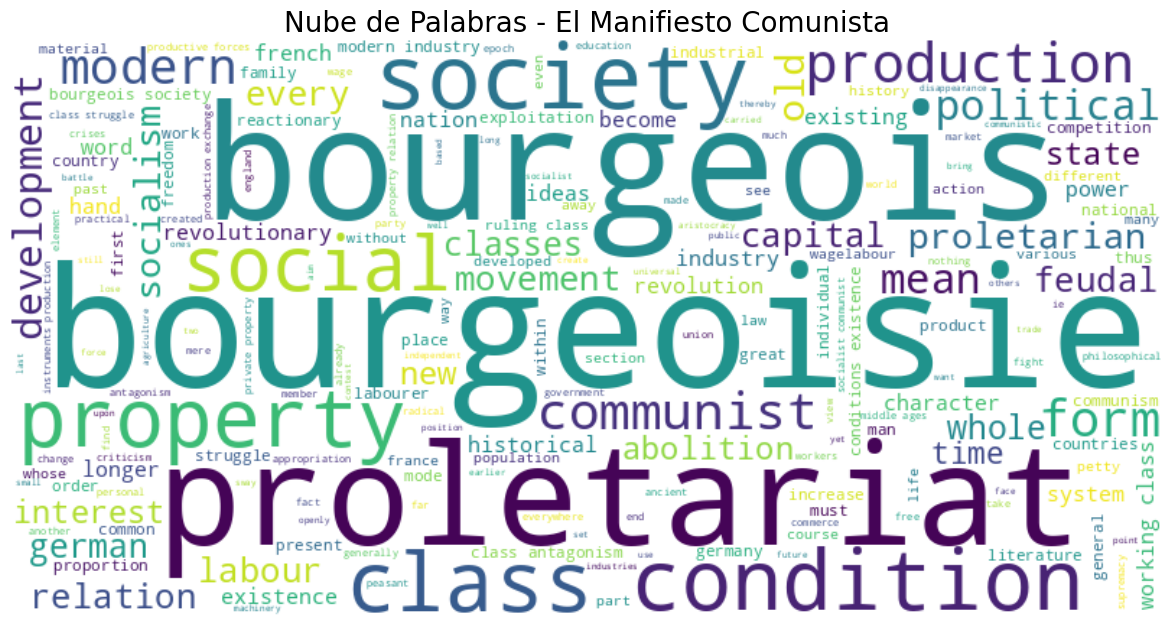

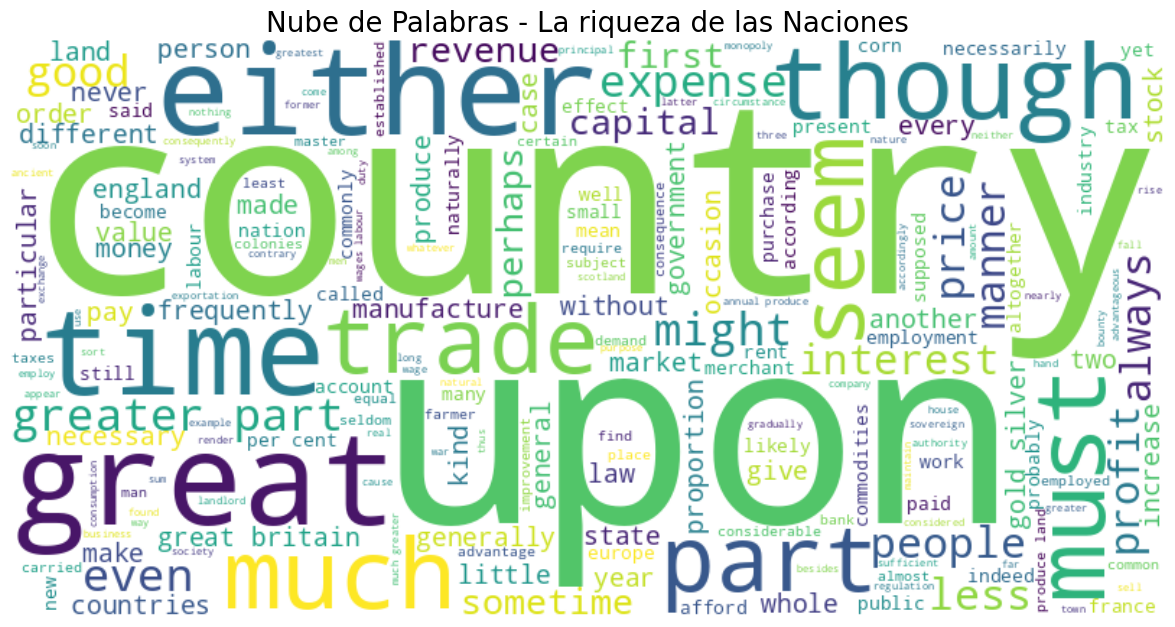

In [ ]:
generar_nube(tokens_manifiesto_limpios, "Nube de Palabras - El Manifiesto Comunista")
generar_nube(tokens_riqueza_limpios, "Nube de Palabras - La riqueza de las Naciones")

---
La siguiente función `grafico_palabras_comunes` muestra gráficamente la frecuencia relativa de las palabras más comunes
En concreto **comparar lado a lado** las palabras más comunes en dos corpus o documentos.
### 1. Argumentos de entrada
* `palabras1` y `palabras2`: listas de tuplas `(palabra, frecuencia)` que representan las palabras más comunes en dos textos distintos.
  Ejemplo: `[("gato", 3), ("perro", 2)]`
* `titulo1`, `titulo2`: etiquetas para identificar cada conjunto (por ejemplo: *Texto A* y *Texto B*).

### 2. Unificación del vocabulario
Para cada texto, se usa `set(...)`, que convierte la lista en un conjunto, elimina duplicados (no necesariamente mantiene el orden original)
```python
palabras = list(set([word for word, fr in palabras1] + [word for word, fr in palabras2]))
```

* Se toma la lista de palabras de ambos textos y se unen ambas en un **set**, eliminando los duplicados.
* Luego se convierte en `list` para poder indexarlas.

Como resultado obtenemos una lista con todas las palabras únicas que aparecen en cualquiera de los dos textos.

### 3. Extracción de frecuencias

```python
fr1 = [dict(palabras1).get(word, 0) for word in palabras]
fr2 = [dict(palabras2).get(word, 0) for word in palabras]
```

* `dict(palabras1)` convierte la lista de tuplas en un diccionario `{palabra: frecuencia}`.
* `.get(word, 0)` devuelve la frecuencia de la palabra, o 0 si no aparece en ese texto.
* Se construyen dos listas, `fr1` y `fr2`, con las frecuencias correspondientes al orden de `palabras`.

### 4. Preparación del gráfico

```python
x = range(len(palabras))
width = 0.35
```

* `x` es el rango de posiciones (0, 1, 2, …) para cada palabra.
* `width` es el ancho de las barras.

### 5. Creación del gráfico de barras agrupadas

```python
plt.bar([i - width/2 for i in x], fr1, width, label=titulo1)
plt.bar([i + width/2 for i in x], fr2, width, label=titulo2)
```

* Se dibuja un par de barras por cada palabra:

  * Una ligeramente desplazada a la izquierda (`i - width/2`).
  * Otra ligeramente a la derecha (`i + width/2`).
* Esto permite **comparar visualmente** la frecuencia de cada palabra entre los dos textos.


In [ ]:
# Gráfico con la frecuencia relativa de las palabras más comunes
def grafico_palabras_comunes(palabras1, palabras2, titulo1, titulo2):
    palabras = list(set([word for word, fr in palabras1] + [word for word, fr in palabras2]))
    fr1 = [dict(palabras1).get(word, 0) for word in palabras]
    fr2 = [dict(palabras2).get(word, 0) for word in palabras]

    x = range(len(palabras))
    width = 0.35

    plt.figure(figsize=(18, 8))
    plt.bar([i - width/2 for i in x], fr1, width, label=titulo1)
    plt.bar([i + width/2 for i in x], fr2, width, label=titulo2)

    plt.xlabel('Palabras', fontsize=14)
    plt.ylabel('Frecuencia Relativa', fontsize=14)
    plt.title('Comparación de las Palabras Más Comunes', fontsize=18)
    plt.xticks(x, palabras, rotation=45)
    plt.legend()
    plt.tight_layout(pad=18)
    plt.show()

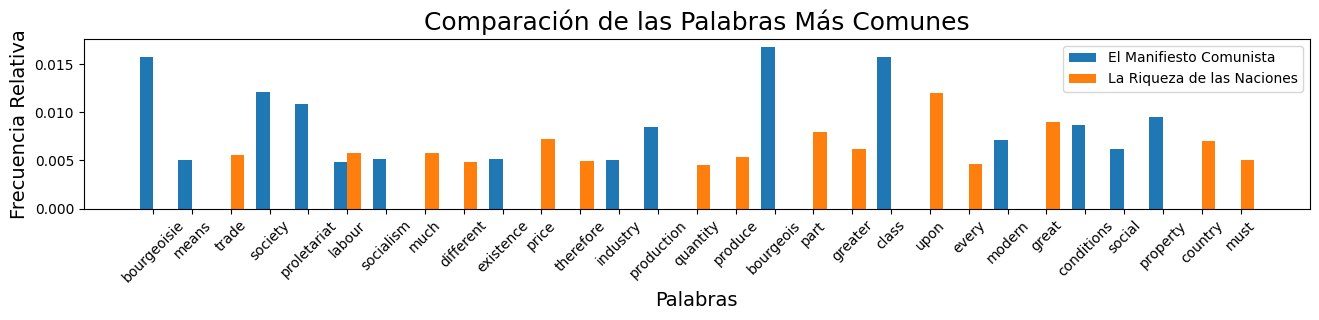

In [ ]:
grafico_palabras_comunes(palabras_comunes_manifiesto, palabras_comunes_riqueza, 'El Manifiesto Comunista', 'La Riqueza de las Naciones')

In [ ]:
# Versión que muestra el gráfico ordenando las palabras por frecuencias
import matplotlib.pyplot as plt

def grafico_palabras_comunes_sorted(palabras1, palabras2, titulo1, titulo2):
    # Convertimos las listas de tuplas en diccionarios
    dict1 = dict(palabras1)
    dict2 = dict(palabras2)

    # Conjunto de palabras únicas
    palabras = list(set(dict1.keys()) | set(dict2.keys()))

    # Calculamos frecuencia total para ordenar
    total_freq = {word: dict1.get(word, 0) + dict2.get(word, 0) for word in palabras}

    # Ordenamos palabras según frecuencia total (descendente)
    palabras = sorted(palabras, key=lambda w: total_freq[w], reverse=True)

    # Frecuencias alineadas al nuevo orden
    fr1 = [dict1.get(word, 0) for word in palabras]
    fr2 = [dict2.get(word, 0) for word in palabras]

    # Gráfico
    x = range(len(palabras))
    width = 0.35

    plt.figure(figsize=(18, 8))
    plt.bar([i - width/2 for i in x], fr1, width, label=titulo1)
    plt.bar([i + width/2 for i in x], fr2, width, label=titulo2)

    plt.xlabel('Palabras', fontsize=14)
    plt.ylabel('Frecuencia Relativa', fontsize=14)
    plt.title('Comparación de las Palabras Más Comunes', fontsize=18)
    plt.xticks(x, palabras, rotation=45)
    plt.legend()
    plt.tight_layout(pad=18)
    plt.show()

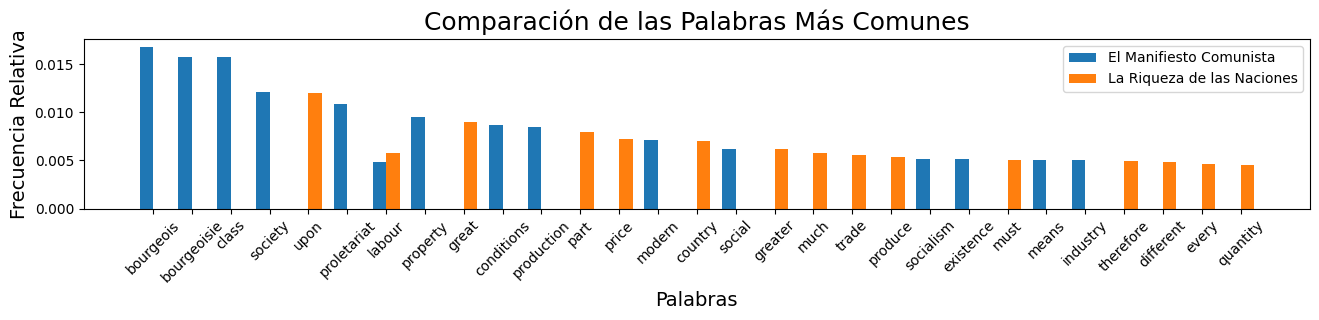

In [ ]:
grafico_palabras_comunes_sorted(palabras_comunes_manifiesto, palabras_comunes_riqueza, 'El Manifiesto Comunista', 'La Riqueza de las Naciones')